# Deep RNN – stacking MLP layers around the recurrent cell


In [ ]:
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Load a tiny text corpus (Shakespeare excerpt is fine for a demo)
with open("./data/shakespeare.txt", encoding="utf-8") as fp:
    text = fp.read().lower()[:50000]

vocab = sorted(set(text))
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = np.array(vocab)

SEQUENCE_LENGTH = 40  # length of each training example
STEP = 3  # stride (helps increase data)
sentences = []
next_chars = []

for i in range(0, len(text) - SEQUENCE_LENGTH, STEP):
    sentences.append(text[i : i + SEQUENCE_LENGTH])
    next_chars.append(text[i + SEQUENCE_LENGTH])

X = np.array([[char2idx[c] for c in s] for s in sentences])
y = np.array([char2idx[c] for c in next_chars])
y = keras.utils.to_categorical(y, num_classes=len(vocab))

In [ ]:
def build_model(depth_before=0, depth_after=1):
    layers = []
    # depth before recurrent
    layers.append(keras.layers.Embedding(len(vocab), output_dim=64))
    for _ in range(depth_before):
        layers.append(
            keras.layers.TimeDistributed(keras.layers.Dense(64, activation="relu"))
        )
    # core recurrent block
    layers.append(keras.layers.LSTM(128, return_sequences=False))
    # depth after recurrent
    for _ in range(depth_after):
        layers.append(keras.layers.Dense(64, activation="relu"))
    # final output
    layers.append(keras.layers.Dense(len(vocab), activation="softmax"))
    return keras.Sequential(layers)

In [ ]:
# Model A: shallow (no extra depth)
N_EPOCHS = 10

model_shallow = build_model()
model_shallow.compile("adam", "categorical_crossentropy")
h_shallow = model_shallow.fit(
    X, y, epochs=N_EPOCHS, batch_size=32, validation_split=0.1
)

# Model B: deep (2 Dense layers before, 1 after)
model_deep = build_model(depth_before=2, depth_after=1)
model_deep.compile("adam", "categorical_crossentropy")
h_deep = model_deep.fit(X, y, epochs=N_EPOCHS, batch_size=32, validation_split=0.1)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - loss: 2.6750 - val_loss: 2.2454
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - loss: 2.1876 - val_loss: 2.0804
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - loss: 2.0522 - val_loss: 1.9944
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - loss: 1.9502 - val_loss: 1.8946
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - loss: 1.8574 - val_loss: 1.8289
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - loss: 1.7925 - val_loss: 1.7930
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 1.7351 - val_loss: 1.7471
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 1.6876 - val_loss: 1.7331
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 1.6448 - val_loss: 1.7143
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 1.6044 - val_loss: 1.6970


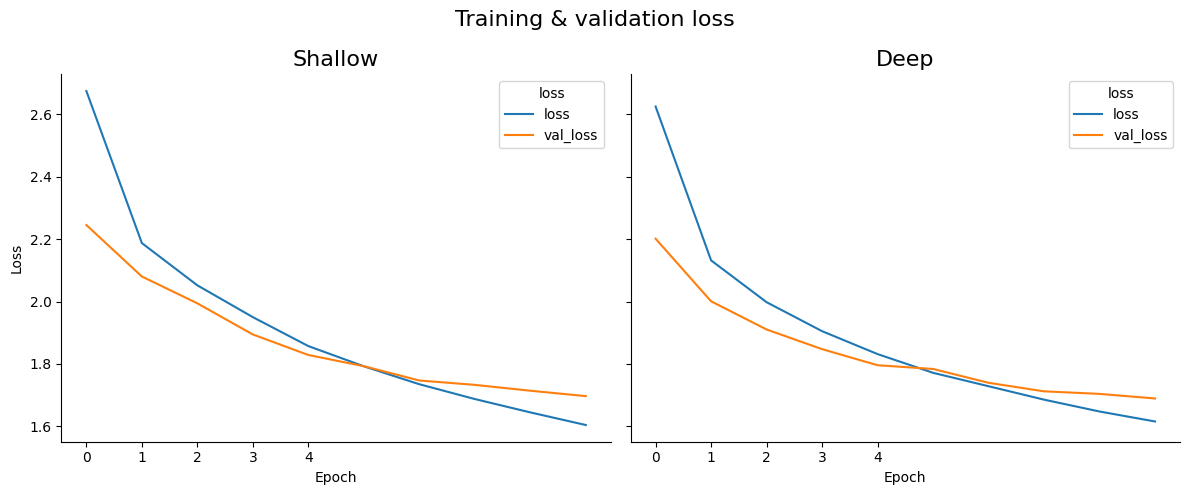

In [ ]:
# Plot loss curves

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, (history, title) in enumerate(zip([h_shallow, h_deep], ["Shallow", "Deep"])):
    history_df = (
        pd.DataFrame(history.history)
        .reset_index(names="epoch")
        .melt(var_name="loss", value_name="score", id_vars="epoch")
    )
    sns.lineplot(data=history_df, x="epoch", y="score", hue="loss", ax=ax[i])
    ax[i].set_title(title, fontsize=16)
    ax[i].set_xticks(np.arange(1, N_EPOCHS + 1))
    ax[i].set_xlabel("Epoch")
    ax[i].set_ylabel("Loss")


fig.suptitle("Training & validation loss", fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()